# 02 — Record Envelope, LP, and Ladder Scaling

Validates the non-monotone running-max envelope structurally and numerically, then tests ladder depth.

**Execution modes:** `SMOKE_TEST=1` performs a small offline code-path check; default settings run a moderate benchmark; `FULL_RUN=1` enables publication-scale Monte Carlo. Smoke outputs are verification-only and must not be reported as experimental results.

In [1]:
from pathlib import Path
import os, sys, math, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path.cwd().resolve()
ROOT = HERE.parent if HERE.name == 'notebooks' else HERE
if not (ROOT/'src'/'gated_benchmarks.py').exists():
    for cand in [HERE, *HERE.parents]:
        if (cand/'src'/'gated_benchmarks.py').exists():
            ROOT = cand; break
sys.path.insert(0, str(ROOT/'src'))
( ROOT/'results').mkdir(exist_ok=True)
( ROOT/'figures').mkdir(exist_ok=True)
FULL_RUN = os.getenv('FULL_RUN','0') == '1'
SMOKE_TEST = os.getenv('SMOKE_TEST','0') == '1'
print('ROOT =', ROOT)
print('FULL_RUN =', FULL_RUN, 'SMOKE_TEST =', SMOKE_TEST)


ROOT = /mnt/data/gated_certification_benchmarks
FULL_RUN = False SMOKE_TEST = True


In [2]:
from gated_benchmarks import *
from scipy.optimize import linprog


## 1. Paper counterexample and other non-monotone patterns

In [3]:
patterns=[
    (np.array([1.9942,1.5369,4.5032]),np.array([.10,.40,1.00]),'paper example'),
    (np.array([1.,4.,2.,5.]),np.array([.08,.15,.4,1.]),'alternating'),
    (np.array([3.,1.,1.5,7.,5.,8.]),np.array([.05,.1,.2,.4,.7,1.]),'deep nonmonotone')]
rows=[]
for K,d,name in patterns:
    closed=ladder_lower_bound(K,d); numeric,x=solve_ladder_lp(K,d)
    rows.append({'name':name,'closed_form':closed,'numeric_lp':numeric,'abs_diff':abs(closed-numeric),'K':K.tolist(),'Kbar':record_envelope(K).tolist(),'Xstar':x.tolist()})
pat=pd.DataFrame(rows); display(pat); pat.to_json(ROOT/'results'/'record_envelope_examples.json',orient='records',indent=2)


,name,closed_form,numeric_lp,abs_diff,K,Kbar,Xstar
0,paper example,22.451,22.451,0.0,"[1.9942, 1.5369, 4.5032]","[1.9942, 1.9942, 4.5032]","[19.942, 0.0, 2.5089999999999995]"
1,alternating,33.500,33.500,0.0,"[1.0, 4.0, 2.0, 5.0]","[1.0, 4.0, 4.0, 5.0]","[12.5, 20.0, 0.0, 1.0]"
2,deep nonmonotone,71.000,71.000,0.0,"[3.0, 1.0, 1.5, 7.0, 5.0, 8.0]","[3.0, 3.0, 3.0, 7.0, 7.0, 8.0]","[60.0, 0.0, 0.0, 10.0, 0.0, 1.0]"


## 2. Random LP verification — 1,000 instances in full mode

In [4]:
rng=np.random.default_rng(42); reps=50 if SMOKE_TEST else (300 if not FULL_RUN else 1000); out=[]
for r in range(reps):
    L=int(rng.integers(2,11)); d=np.sort(rng.uniform(.03,2.0,L)); K=rng.uniform(.1,8.0,L)
    closed=ladder_lower_bound(K,d); num,x=solve_ladder_lp(K,d)
    out.append({'rep':r,'L':L,'closed':closed,'numeric':num,'abs_diff':abs(closed-num),'max_K_drop':float(np.max(np.maximum(0,-np.diff(K)))) if L>1 else 0})
rnd=pd.DataFrame(out); display(rnd.describe()); print('max abs error=',rnd.abs_diff.max())
rnd.to_csv(ROOT/'results'/'random_lp_verification.csv',index=False)
assert rnd.abs_diff.max() < 1e-7


,rep,L,closed,numeric,abs_diff,max_K_drop
count,50.00000,50.000000,50.000000,50.000000,5.000000e+01,50.000000
mean,24.50000,5.780000,29.557186,29.557186,2.131628e-16,3.582784
std,14.57738,2.628649,30.391205,30.391205,1.054882e-15,2.051055
min,0.00000,2.000000,3.886899,3.886899,0.000000e+00,0.000000
25%,12.25000,3.250000,10.023094,10.023094,0.000000e+00,2.107380
50%,24.50000,6.000000,20.275034,20.275034,0.000000e+00,3.951782
75%,36.75000,8.000000,37.582293,37.582293,0.000000e+00,5.200159
max,49.00000,10.000000,162.140792,162.140792,7.105427e-15,6.857468


max abs error= 7.105427357601002e-15


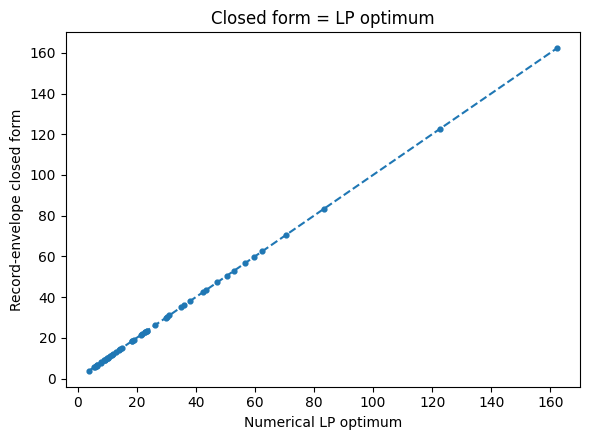

In [5]:
fig,ax=plt.subplots(figsize=(6,4.5)); ax.scatter(rnd.numeric,rnd.closed,s=12); lo=min(rnd.numeric.min(),rnd.closed.min()); hi=max(rnd.numeric.max(),rnd.closed.max()); ax.plot([lo,hi],[lo,hi],linestyle='--'); ax.set_xlabel('Numerical LP optimum'); ax.set_ylabel('Record-envelope closed form'); ax.set_title('Closed form = LP optimum'); fig.tight_layout(); fig.savefig(ROOT/'figures'/'lp_verification.png',dpi=180); plt.show()


## 3. Ladder-depth scaling

,L,C_gate,PoC,d1,dL
0,2,10.500000,10.500000,0.05,1.0
1,3,8.490712,8.490712,0.05,1.0
2,5,7.408859,7.408859,0.05,1.0
3,10,6.810726,6.810726,0.05,1.0


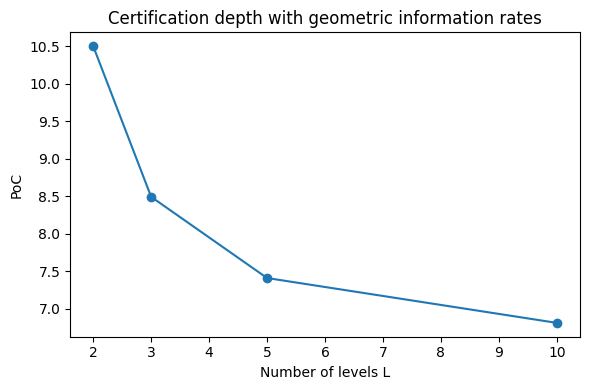

In [6]:
depth_rows=[]
for L in [2,3,5,10]:
    d=np.geomspace(.05,1.0,L); r=np.linspace(0,1,L+1); c=theoretical_c_gate(d,r); poc=price_of_certification(d,r)
    depth_rows.append({'L':L,'C_gate':c,'PoC':poc,'d1':d[0],'dL':d[-1]})
depth=pd.DataFrame(depth_rows); display(depth); depth.to_csv(ROOT/'results'/'ladder_depth_scaling.csv',index=False)
fig,ax=plt.subplots(figsize=(6,4)); ax.plot(depth.L,depth.PoC,marker='o'); ax.set_xlabel('Number of levels L'); ax.set_ylabel('PoC'); ax.set_title('Certification depth with geometric information rates'); fig.tight_layout(); fig.savefig(ROOT/'figures'/'ladder_depth.png',dpi=180); plt.show()


## 4. Sequential multi-level validation (L=2,3,5,10)

,L,delta,C_gate,emp_norm_tau,mean_tau,error_rate,failed_unlock_rate,PoC_theory,d1,dL
0,2,0.02,40.253284,49.991185,195.566667,0.033333,0.033333,14.815793,0.012855,0.368064
1,3,0.02,29.611213,27.752052,108.566667,0.033333,0.033333,10.898828,0.012855,0.368064
2,5,0.02,22.506539,23.099728,90.366667,0.000000,0.000000,8.283851,0.012855,0.368064
3,10,0.02,18.318229,24.250028,94.866667,0.000000,0.000000,6.742285,0.012855,0.368064


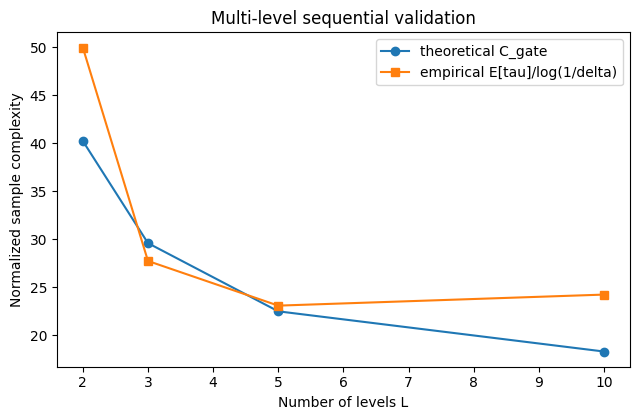

In [7]:
seq_rows=[]
delta_seq=.02
nseq=30 if SMOKE_TEST else (300 if not FULL_RUN else 2000)
for L in [2,3,5,10]:
    # Bernoulli actions with progressively larger KL against H1=Bernoulli(.5).
    p0s=np.linspace(.58,.90,L)
    acts=[BernoulliAction(float(p0),.50,f'level_{i+1}') for i,p0 in enumerate(p0s)]
    dvec=np.array([a.d0 for a in acts])
    rho_pts=np.linspace(0,1,L+1)
    alphas=(delta_seq**rho_pts[1:L]).tolist()
    C=theoretical_c_gate(dvec,rho_pts)
    df=simulate_binary_ladder(acts,alphas,delta_seq,0,n_trials=nseq,seed=500+L,policy='running_max',max_steps=100000)
    sm=summarize_binary_runs(df)
    seq_rows.append({'L':L,'delta':delta_seq,'C_gate':C,'emp_norm_tau':sm['mean_tau']/math.log(1/delta_seq),
                     'mean_tau':sm['mean_tau'],'error_rate':sm['error_rate'],
                     'failed_unlock_rate':sm['failed_unlock_rate'],'PoC_theory':price_of_certification(dvec,rho_pts),
                     'd1':dvec[0],'dL':dvec[-1]})
seq_depth=pd.DataFrame(seq_rows); display(seq_depth)
seq_depth.to_csv(ROOT/'results'/'ladder_depth_empirical.csv',index=False)
fig,ax=plt.subplots(figsize=(6.5,4.3)); ax.plot(seq_depth.L,seq_depth.C_gate,marker='o',label='theoretical C_gate'); ax.plot(seq_depth.L,seq_depth.emp_norm_tau,marker='s',label='empirical E[tau]/log(1/delta)'); ax.set_xlabel('Number of levels L'); ax.set_ylabel('Normalized sample complexity'); ax.set_title('Multi-level sequential validation'); ax.legend(); fig.tight_layout(); fig.savefig(ROOT/'figures'/'ladder_depth_empirical.png',dpi=180); plt.show()


## 5. Epistemic-trap numerical illustration

In [8]:
# Weak action has KL=0; adding epsilon separation makes certification finite but expensive.
eps=[0,.005,.01,.02,.05,.1]; rows=[]
for e in eps:
    p0=.5+e; p1=.5
    d=0.0 if e==0 else kl_bernoulli(p0,p1)
    approx=np.inf if d==0 else math.log(1/.05)/d
    rows.append({'epsilon':e,'weak_KL':d,'approx_samples_to_certificate':approx})
trap=pd.DataFrame(rows); display(trap); trap.to_csv(ROOT/'results'/'trap_scaling.csv',index=False)


,epsilon,weak_KL,approx_samples_to_certificate
0,0.000,0.000000,inf
1,0.005,0.000050,5.991365e+04
2,0.010,0.000200,1.497766e+04
3,0.020,0.000800,3.743666e+03
4,0.050,0.005008,5.981455e+02
5,0.100,0.020136,1.487785e+02
